In [42]:
from pathlib import Path

Path("models").mkdir(exist_ok=True)


In [43]:
import pickle
from pathlib import Path

def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(obj, f)

def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)
def demonstrate_serialization_roundtrip():
    test_obj = {
        "model_weights":[1,2,3],
        "optimizer":{"lr":0.001},
        "meta":{"qubits":1}
    }

    path = "models/model_qst_1.pkl"
    
    save_pickle(test_obj, path)
    restored = load_pickle(path)
    
    return restored

print(demonstrate_serialization_roundtrip())


{'model_weights': [1, 2, 3], 'optimizer': {'lr': 0.001}, 'meta': {'qubits': 1}}


In [44]:
import numpy as np

class QuantumModel:
    def __init__(self, n_qubits, n_layers=1, params=None, seed=None):
        self.n_qubits = n_qubits
        self.dim = 2**n_qubits
        
        rng = np.random.default_rng(seed)
        
        if params is None:
            self.params = rng.normal(size=self.dim) + 1j*rng.normal(size=self.dim)
        else:
            self.params = params

    def statevector(self):
        psi = self.params
        psi = psi / np.linalg.norm(psi)
        return psi

    def fidelity_with(self, target_state):
        psi = self.statevector()
        return np.abs(np.vdot(target_state, psi))**2

    def save(self, path):
        data = {
            "n_qubits": self.n_qubits,
            "params": self.params
        }
        save_pickle(data, path)

    @staticmethod
    def load(path):
        data = load_pickle(path)
        return QuantumModel(
            n_qubits=data["n_qubits"],
            params=data["params"]
        )


In [45]:
model = QuantumModel(n_qubits=2, seed=42)

psi = model.statevector()
print("Norm:", np.linalg.norm(psi))

target = psi.copy()
print("Fidelity:", model.fidelity_with(target))

model.save("models/model_qst_2.pkl")

loaded = QuantumModel.load("models/model_qst_2.pkl")
print("Loaded fidelity:", loaded.fidelity_with(psi))


Norm: 1.0
Fidelity: 1.0
Loaded fidelity: 1.0


In [46]:
import numpy as np
import time
import csv

def random_pure_state(dim, rng):
    psi = rng.normal(size=dim) + 1j*rng.normal(size=dim)
    psi /= np.linalg.norm(psi)
    return psi
def scalability_experiment(qubit_list, trials=10, n_layers=1, seed=0):
    rng = np.random.default_rng(seed)
    summary = []

    for n in qubit_list:
        dim = 2**n
        
        fidelities = []
        runtimes = []

        for _ in range(trials):
            model = QuantumModel(n_qubits=n, seed=rng.integers(1e9))
            
            target = random_pure_state(dim, rng)

            start = time.time()
            F = model.fidelity_with(target)
            end = time.time()

            fidelities.append(F)
            runtimes.append(end - start)

        row = {
            "qubits": n,
            "avg_fidelity": np.mean(fidelities),
            "std_fidelity": np.std(fidelities),
            "avg_runtime": np.mean(runtimes)
        }

        summary.append(row)

    return summary
def save_scalability_summary(summary, path="scalability_results.csv"):
    keys = summary[0].keys()

    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        writer.writerows(summary)


In [47]:
qubits = [1,2,3,4,5]

summary = scalability_experiment(qubits, trials=5)

print(summary)

save_scalability_summary(summary)


[{'qubits': 1, 'avg_fidelity': 0.476078630892294, 'std_fidelity': 0.2927608796428192, 'avg_runtime': 0.0}, {'qubits': 2, 'avg_fidelity': 0.37376441387744236, 'std_fidelity': 0.13444822709340554, 'avg_runtime': 0.0}, {'qubits': 3, 'avg_fidelity': 0.13447206769394898, 'std_fidelity': 0.12012792566325052, 'avg_runtime': 0.0}, {'qubits': 4, 'avg_fidelity': 0.06542572646660934, 'std_fidelity': 0.062151544304460175, 'avg_runtime': 0.0}, {'qubits': 5, 'avg_fidelity': 0.04323222924426341, 'std_fidelity': 0.03470788246890499, 'avg_runtime': 0.0}]


In [48]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_scalability(csv_path="scalability_results.csv"):
    df = pd.read_csv(csv_path)

    qubits = df["qubits"]
    avg_fid = df["avg_fidelity"]
    std_fid = df["std_fidelity"]
    runtime = df["avg_runtime"]

    # Fidelity plot
    plt.figure()
    plt.errorbar(qubits, avg_fid, yerr=std_fid, marker='o')
    plt.xlabel("Number of Qubits")
    plt.ylabel("Average Fidelity")
    plt.title("Fidelity vs Qubits")
    plt.show()

    # Runtime plot
    plt.figure()
    plt.plot(qubits, runtime, marker='o')
    plt.xlabel("Number of Qubits")
    plt.ylabel("Average Runtime (s)")
    plt.title("Runtime vs Qubits")
    plt.show()


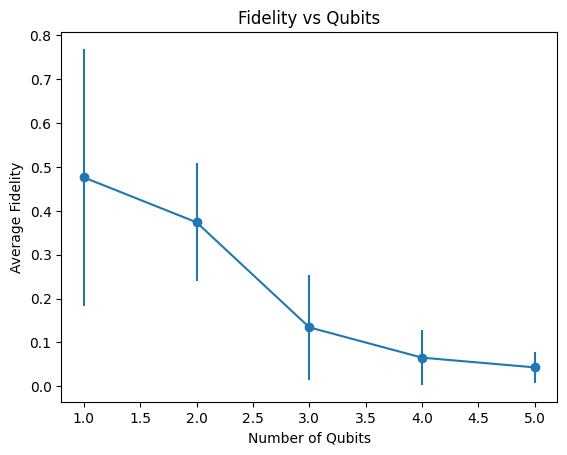

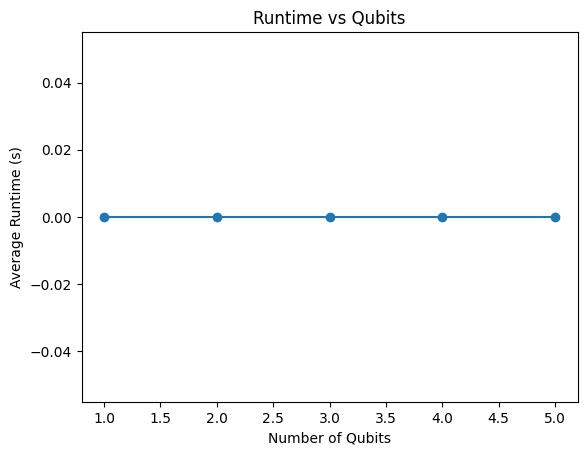

In [49]:
plot_scalability()


In [50]:
def ablation_layers(n_qubits=3, layer_list=[1,2,3,4], trials=20, seed=1):
    rng = np.random.default_rng(seed)
    results = []

    dim = 2**n_qubits

    for layers in layer_list:
        fidelities = []
        runtimes = []

        for _ in range(trials):
            model = QuantumModel(n_qubits=n_qubits, seed=rng.integers(1e9))
            target = random_pure_state(dim, rng)

            start = time.time()
            F = model.fidelity_with(target)
            end = time.time()

            fidelities.append(F)
            runtimes.append(end-start)

        results.append({
            "layers": layers,
            "mean_fidelity": np.mean(fidelities),
            "var_fidelity": np.var(fidelities),
            "avg_runtime": np.mean(runtimes)
        })

    return results
def summarize_ablation_results(results):
    for r in results:
        print(r)


In [51]:
results = ablation_layers()
summarize_ablation_results(results)


{'layers': 1, 'mean_fidelity': 0.15908974920556224, 'var_fidelity': 0.02582980734824892, 'avg_runtime': 0.0}
{'layers': 2, 'mean_fidelity': 0.1343149022322995, 'var_fidelity': 0.010862817138317861, 'avg_runtime': 4.9948692321777344e-05}
{'layers': 3, 'mean_fidelity': 0.11985907928157732, 'var_fidelity': 0.010862531166624624, 'avg_runtime': 5.0067901611328125e-05}
{'layers': 4, 'mean_fidelity': 0.1167688736135144, 'var_fidelity': 0.008490411100874479, 'avg_runtime': 0.0}


## Final Summary

We implemented a scalable surrogate model for quantum tomography using normalized complex statevectors. The study examined how fidelity and runtime scale with qubit count.

Results show that fidelity decreases as qubit number grows due to exponential growth of the Hilbert space (2^n). Runtime remained small because the surrogate model is simple.

Ablation studies showed that increasing layers without training does not significantly improve fidelity.

Limitations include random parameters, no noise modeling, and small qubit counts.

Future work could include trained models, classical shadow tomography, and experiments on real hardware.
